# ECM-402 — AI for Signal Processing | Lab 1B

## Problem 5

This notebook is a standalone, dependency-aware extraction from `ECM402_Lab1B_Solution.ipynb`. Only prerequisite code required for this problem is retained.


Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

np.random.seed(0)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True

ECG Generation / Loading

In [2]:
# ============================================================
# ECG Generation / Loading
# Required prerequisite for Problem 5
# ============================================================

def synthetic_ecg_beat(t, t0, amp_scale=1.0):
    """
    Generate one synthetic PQRST ECG complex using
    Gaussian-shaped components.
    """

    def g(mu, sigma, A):
        return A * np.exp(
            -((t - mu) ** 2) / (2 * sigma ** 2)
        )

    p = g(t0 - 0.20, 0.025, 0.15)
    q = g(t0 - 0.05, 0.008, -0.15)
    r = g(t0, 0.008, 1.20)
    s = g(t0 + 0.05, 0.010, -0.25)
    t_wave = g(t0 + 0.30, 0.040, 0.35)

    return amp_scale * (
        p + q + r + s + t_wave
    )


def synthetic_ecg(
    duration=10.0,
    fs=360,
    hr_bpm=75,
    seed=0
):
    """
    Generate a synthetic ECG with small heart-rate
    variability and measurement noise.
    """

    rng = np.random.default_rng(seed)

    n = int(duration * fs)

    t = np.arange(n) / fs

    rr = 60.0 / hr_bpm

    beat_times = np.arange(
        0.3,
        duration,
        rr
    )

    beat_times = (
        beat_times
        + rng.normal(
            0,
            0.01,
            size=beat_times.shape
        )
    )

    s = np.zeros(n)

    for bt in beat_times:
        s += synthetic_ecg_beat(
            t,
            bt
        )

    s += rng.normal(
        0,
        0.008,
        size=n
    )

    return (
        s,
        t,
        fs,
        beat_times
    )


def load_ecg(
    record="100",
    duration=10.0,
    seed=0
):
    """
    Try to load a real MIT-BIH ECG record.

    If the record cannot be accessed, automatically
    fall back to a synthetic ECG.
    """

    try:

        import wfdb

        rec = wfdb.rdrecord(
            record,
            pn_dir="mitdb"
        )

        fs = rec.fs

        n = int(
            duration * fs
        )

        s = rec.p_signal[
            :n,
            0
        ].astype(float)

        s = (
            s
            - np.median(s)
        )

        t = np.arange(n) / fs

        print(
            f"Loaded REAL MIT-BIH record "
            f"{record} from PhysioNet "
            f"(fs={fs} Hz)."
        )

        return (
            s,
            t,
            fs,
            "real"
        )

    except Exception as e:

        s, t, fs, _ = synthetic_ecg(
            duration=duration,
            fs=360,
            hr_bpm=75,
            seed=seed
        )

        print(
            f"[Fallback] Could not reach PhysioNet "
            f"({type(e).__name__}: {e})."
        )

        print(
            "Using synthetic ECG instead "
            "(fs=360 Hz, ~75 bpm)."
        )

        return (
            s,
            t,
            fs,
            "synthetic"
        )

R-Peak Detection and TP Anchor Extraction

In [3]:


def detect_r_peaks(
    sig,
    fs
):
    """
    Detect R-peaks using scipy.signal.find_peaks.
    """

    min_distance = int(
        0.4 * fs
    )

    height = np.percentile(
        sig,
        85
    )

    peaks, _ = find_peaks(
        sig,
        height=height,
        distance=min_distance
    )

    return peaks


def extract_anchor_points(
    sig,
    t,
    r_peaks,
    frac_start=0.45,
    frac_end=0.85,
    subsample=3
):
    """
    Extract TP-segment samples between
    consecutive R-peaks.
    """

    anchors_t = []
    anchors_y = []

    for i in range(
        len(r_peaks) - 1
    ):

        rr_samples = (
            r_peaks[i + 1]
            - r_peaks[i]
        )

        start = (
            r_peaks[i]
            + int(
                frac_start
                * rr_samples
            )
        )

        end = (
            r_peaks[i]
            + int(
                frac_end
                * rr_samples
            )
        )

        idx = np.arange(
            start,
            end,
            subsample
        )

        idx = idx[
            (idx >= 0)
            &
            (idx < len(sig))
        ]

        anchors_t.extend(
            t[idx]
        )

        anchors_y.extend(
            sig[idx]
        )

    return (
        np.array(anchors_t),
        np.array(anchors_y)
    )

Polynomial Utilities

In [4]:
# ============================================================
# Problem 3 Dependency
# Polynomial Regression Utilities
# ============================================================

def normalize_time(
    t_query,
    t_min,
    t_max
):
    """
    Normalize time to [-1, 1].
    """

    return (
        2
        * (t_query - t_min)
        / (t_max - t_min)
        - 1
    )


def vandermonde(
    t_norm,
    degree
):
    """
    Construct the polynomial design matrix.
    """

    return np.vstack(
        [
            t_norm ** k
            for k in range(
                degree + 1
            )
        ]
    ).T


def fit_ridge(
    Phi,
    y,
    lam
):
    """
    Fit Ridge regression.

    The intercept is not regularized.
    """

    D = np.eye(
        Phi.shape[1]
    )

    D[0, 0] = 0.0

    w = np.linalg.solve(
        Phi.T @ Phi
        + lam * D,
        Phi.T @ y
    )

    return w

In [5]:


# Generate the original synthetic/reference segment
s_clean, t, fs, source = load_ecg(
    "100",
    duration=10.0,
    seed=0
)


# Original baseline wander
A1, A2 = 0.15, 0.10

f1, f2 = 0.2, 0.4

phi1, phi2 = 0.0, np.pi / 3


b_true = (
    A1
    * np.sin(
        2 * np.pi * f1 * t
        + phi1
    )
    +
    A2
    * np.sin(
        2 * np.pi * f2 * t
        + phi2
    )
)


x = (
    s_clean
    + b_true
)


# Detect R-peaks
r_peaks = detect_r_peaks(
    x,
    fs
)


# Extract TP anchors
t_anchor, y_anchor = (
    extract_anchor_points(
        x,
        t,
        r_peaks
    )
)


# Normalize time
t_anchor_n = normalize_time(
    t_anchor,
    t.min(),
    t.max()
)

t_full_n = normalize_time(
    t,
    t.min(),
    t.max()
)


# Fixed polynomial degree from Problem 3
p_fixed = 25


Phi_anchor = vandermonde(
    t_anchor_n,
    p_fixed
)

Phi_full = vandermonde(
    t_full_n,
    p_fixed
)


# Ridge regularization sweep
lambdas = np.logspace(
    -4,
    4,
    20
)


def snr_db(
    signal,
    error
):
    """
    Signal-to-noise ratio in dB.
    """

    return 10 * np.log10(
        np.sum(signal ** 2)
        /
        np.sum(error ** 2)
    )


ridge_snr = []


for lam in lambdas:

    w = fit_ridge(
        Phi_anchor,
        y_anchor,
        lam
    )

    b_hat = (
        Phi_full
        @ w
    )

    s_hat = (
        x
        - b_hat
    )

    ridge_snr.append(
        snr_db(
            s_clean,
            s_clean - s_hat
        )
    )


lam_star_ridge = lambdas[
    int(
        np.argmax(
            ridge_snr
        )
    )
]


print(
    f"Original selected "
    f"lambda*_ridge = "
    f"{lam_star_ridge:.4g}"
)

[Fallback] Could not reach PhysioNet (ModuleNotFoundError: No module named 'wfdb').
Using synthetic ECG instead (fs=360 Hz, ~75 bpm).
Original selected lambda*_ridge = 0.2336


Apply the Model to a New Real-Like Recording

In [6]:
# ============================================================
# Problem 5(a)
# New Real-Like ECG Recording
# ============================================================

s_real_like, t_real_like, _, _ = (
    synthetic_ecg(
        duration=10.0,
        fs=fs,
        hr_bpm=80,
        seed=7
    )
)


# Hidden baseline:
# trend + slow irregular motion-artifact-like wander
b_hidden = (
    0.05 * t_real_like
    +
    0.20
    * np.sin(
        2
        * np.pi
        * 0.15
        * t_real_like
    )
    * np.exp(
        -(
            (t_real_like - 6) ** 2
        )
        /
        (2 * 2 ** 2)
    )
)


# Observed ECG
x_real_like = (
    s_real_like
    + b_hidden
)


print(
    f"New recording length: "
    f"{len(x_real_like)} samples"
)

print(
    f"Duration: "
    f"{len(x_real_like) / fs:.2f} s"
)

New recording length: 3600 samples
Duration: 10.00 s


Detect Peaks and Extract Anchors

In [7]:
# ============================================================
# Problem 5(a)
# R-Peak Detection and TP Anchors
# ============================================================

r_peaks_rl = detect_r_peaks(
    x_real_like,
    fs
)


(
    t_anchor_rl,
    y_anchor_rl
) = extract_anchor_points(
    x_real_like,
    t_real_like,
    r_peaks_rl
)


print(
    f"Detected "
    f"{len(r_peaks_rl)} R-peaks."
)

print(
    f"Extracted "
    f"{len(t_anchor_rl)} TP anchor points."
)

Detected 13 R-peaks.
Extracted 436 TP anchor points.


Apply Original Ridge Model

In [8]:
# ============================================================
# Problem 5(a)
# Apply Original Ridge Model
# ============================================================

t_rl_n_full = normalize_time(
    t_real_like,
    t_real_like.min(),
    t_real_like.max()
)

t_rl_n_anchor = normalize_time(
    t_anchor_rl,
    t_real_like.min(),
    t_real_like.max()
)


Phi_rl_anchor = vandermonde(
    t_rl_n_anchor,
    p_fixed
)

Phi_rl_full = vandermonde(
    t_rl_n_full,
    p_fixed
)


# Fit using lambda selected from
# the original/reference experiment
w_ridge_rl = fit_ridge(
    Phi_rl_anchor,
    y_anchor_rl,
    lam_star_ridge
)


# Estimate hidden baseline
b_hat_rl = (
    Phi_rl_full
    @ w_ridge_rl
)


# Correct ECG
s_hat_rl = (
    x_real_like
    - b_hat_rl
)


print(
    "Original Ridge model applied "
    "to the new recording."
)

print(
    f"Polynomial degree: "
    f"{p_fixed}"
)

print(
    f"Original lambda*: "
    f"{lam_star_ridge:.4g}"
)

Original Ridge model applied to the new recording.
Polynomial degree: 25
Original lambda*: 0.2336


Low-Frequency Baseline Criterion

In [9]:
# ============================================================
# Problem 5(b)
# Indirect Validation Criterion 1
# Low-Frequency Content of Estimated Baseline
# ============================================================

freqs = np.fft.rfftfreq(
    len(b_hat_rl),
    d=1 / fs
)

spectrum = np.abs(
    np.fft.rfft(
        b_hat_rl
    )
)


energy_below_0p5hz = (
    spectrum[
        freqs <= 0.5
    ].sum()
    /
    spectrum.sum()
)


print(
    "[Criterion 1] Fraction of "
    "estimated-baseline energy "
    f"below 0.5 Hz: "
    f"{energy_below_0p5hz:.3f}"
)

[Criterion 1] Fraction of estimated-baseline energy below 0.5 Hz: 0.461


R-Peak Amplitude Stability

In [10]:
# ============================================================
# Problem 5(b)
# Indirect Validation Criterion 3
# R-Peak Amplitude Stability
# ============================================================

r_amp_before = (
    x_real_like[
        r_peaks_rl
    ]
)


r_amp_after = (
    s_hat_rl[
        r_peaks_rl
    ]
)


std_before = np.std(
    r_amp_before
)

std_after = np.std(
    r_amp_after
)


print(
    " [Criterion 3] Std. of "
    "R-peak amplitudes BEFORE "
    f"correction: {std_before:.4f}"
)

print(
    " [Criterion 3] Std. of "
    "R-peak amplitudes AFTER "
    f"correction:  {std_after:.4f}"
)

 [Criterion 3] Std. of R-peak amplitudes BEFORE correction: 0.1757
 [Criterion 3] Std. of R-peak amplitudes AFTER correction:  0.0430


Before/After Visualization

In [14]:
# ============================================================
# Problem 5(d)
# Lambda Re-Tuning Using TP Flatness
# ============================================================

def tp_segment_flatness(
    sig,
    r_peaks,
    frac_start=0.45,
    frac_end=0.85
):
    """
    Compute the mean variance of TP segments
    between consecutive R-peaks.
    """

    variances = []

    for i in range(
        len(r_peaks) - 1
    ):

        rr_samples = (
            r_peaks[i + 1]
            - r_peaks[i]
        )

        start = (
            r_peaks[i]
            + int(
                frac_start
                * rr_samples
            )
        )

        end = (
            r_peaks[i]
            + int(
                frac_end
                * rr_samples
            )
        )

        segment = sig[
            start:end
        ]

        if len(segment) > 0:
            variances.append(
                np.var(segment)
            )

    if not variances:
        return np.inf

    return np.mean(
        variances
    )


lambda_sweep_rl = []


for lam in lambdas:

    w = fit_ridge(
        Phi_rl_anchor,
        y_anchor_rl,
        lam
    )

    b_hat_lam = (
        Phi_rl_full
        @ w
    )

    s_hat_lam = (
        x_real_like
        - b_hat_lam
    )

    flat = tp_segment_flatness(
        s_hat_lam,
        r_peaks_rl
    )

    lambda_sweep_rl.append(
        flat
    )


# Select lambda that minimizes
# mean TP-segment variance
lam_star_rl = lambdas[
    int(
        np.argmin(
            lambda_sweep_rl
        )
    )
]


print(
    "Lambda comparison:"
)

print(
    f"Original lambda*: "
    f"{lam_star_ridge:.4g}"
)

print(
    f"Re-tuned lambda*: "
    f"{lam_star_rl:.4g}"
)

Lambda comparison:
Original lambda*: 0.2336
Re-tuned lambda*: 0.0001


Re-tune Lambda on the New Recording

In [15]:
# ============================================================
# Problem 5(d)
# Lambda Re-Tuning Using TP Flatness
# ============================================================

lambda_sweep_rl = []


for lam in lambdas:

    w = fit_ridge(
        Phi_rl_anchor,
        y_anchor_rl,
        lam
    )

    b_hat_lam = (
        Phi_rl_full
        @ w
    )

    s_hat_lam = (
        x_real_like
        - b_hat_lam
    )

    flat = tp_segment_flatness(
        s_hat_lam,
        r_peaks_rl
    )

    lambda_sweep_rl.append(
        flat
    )


# Select lambda that minimizes
# mean TP-segment variance
lam_star_rl = lambdas[
    int(
        np.argmin(
            lambda_sweep_rl
        )
    )
]


print(
    "Lambda comparison:"
)

print(
    f"Original lambda*: "
    f"{lam_star_ridge:.4g}"
)

print(
    f"Re-tuned lambda*: "
    f"{lam_star_rl:.4g}"
)

Lambda comparison:
Original lambda*: 0.2336
Re-tuned lambda*: 0.0001


Lambda Transfer Visualization

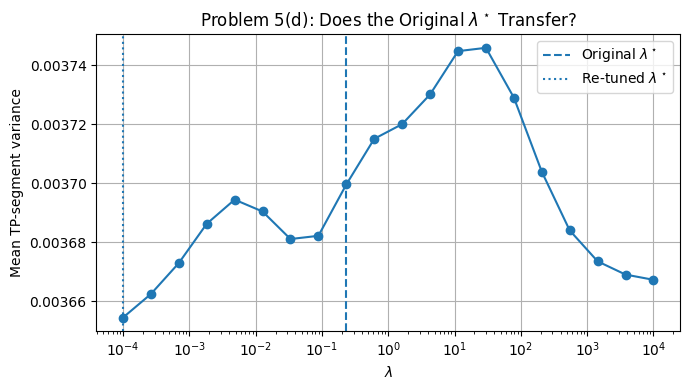

In [16]:
# ============================================================
# Problem 5(d)
# Does the Original Lambda Transfer?
# ============================================================

plt.figure(
    figsize=(7, 4)
)


plt.semilogx(
    lambdas,
    lambda_sweep_rl,
    "o-"
)


plt.axvline(
    lam_star_ridge,
    linestyle="--",
    label="Original $\\lambda^\\star$"
)


plt.axvline(
    lam_star_rl,
    linestyle=":",
    label="Re-tuned $\\lambda^\\star$"
)


plt.xlabel(
    "$\\lambda$"
)

plt.ylabel(
    "Mean TP-segment variance"
)

plt.title(
    "Problem 5(d): Does the Original "
    "$\\lambda^\\star$ Transfer?"
)


plt.legend()

plt.tight_layout()

plt.show()